<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1789 | Val: 434 | Test: 284


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ResNet-50] Epoch   1/100 | LR: 1.00e-04 | train loss 1.2163 acc 0.511 | val loss 0.9004 acc 0.629 *


[ResNet-50] Epoch   2/100 | LR: 1.00e-04 | train loss 0.7429 acc 0.671 | val loss 0.7193 acc 0.652 *


[ResNet-50] Epoch   3/100 | LR: 1.00e-04 | train loss 0.5851 acc 0.743 | val loss 0.6094 acc 0.763 *


[ResNet-50] Epoch   4/100 | LR: 1.00e-04 | train loss 0.4419 acc 0.794 | val loss 0.4884 acc 0.793 *


...

[ResNet-50] Epoch  15/100 | LR: 1.00e-05 | train loss 0.1253 acc 0.945 | val loss 0.4606 acc 0.834


[ResNet-50] Epoch  16/100 | LR: 1.00e-05 | train loss 0.1122 acc 0.951 | val loss 0.4272 acc 0.855


[ResNet-50] Epoch  17/100 | LR: 1.00e-05 | train loss 0.0735 acc 0.971 | val loss 0.4350 acc 0.855


[ResNet-50] Epoch  18/100 | LR: 1.00e-05 | train loss 0.0683 acc 0.975 | val loss 0.4648 acc 0.857


[ResNet-50] Epoch  19/100 | LR: 1.00e-05 | train loss 0.0671 acc 0.970 | val loss 0.4769 acc 0.853

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 19.

[ResNet-50] Restored best checkpoint (val loss = 0.4036)


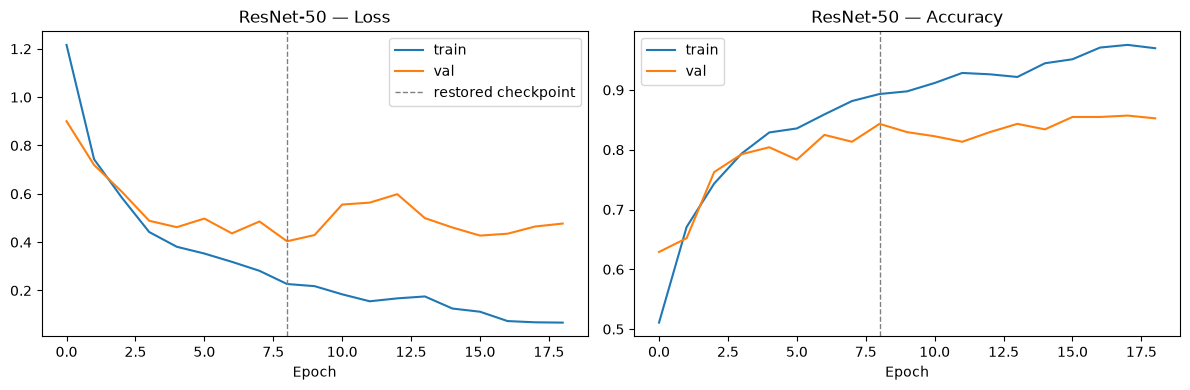

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.799


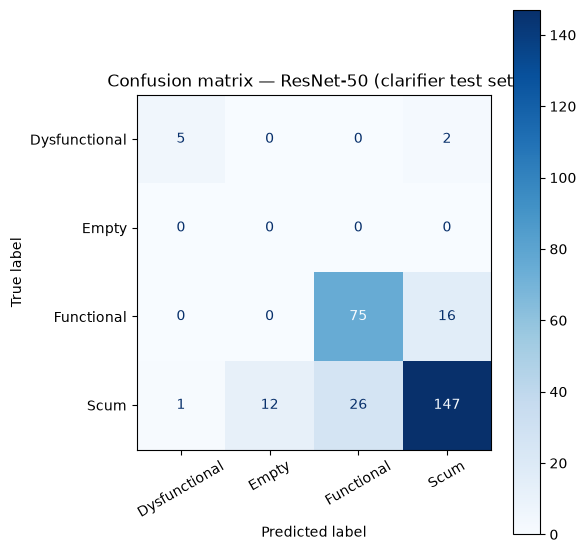

               precision    recall  f1-score   support

Dysfunctional      0.833     0.714     0.769         7
        Empty      0.000     0.000     0.000         0
   Functional      0.743     0.824     0.781        91
         Scum      0.891     0.790     0.838       186

     accuracy                          0.799       284
    macro avg      0.617     0.582     0.597       284
 weighted avg      0.842     0.799     0.818       284

  [warn] 'Empty' has 0 examples in this test set — AUC undefined, skipping.


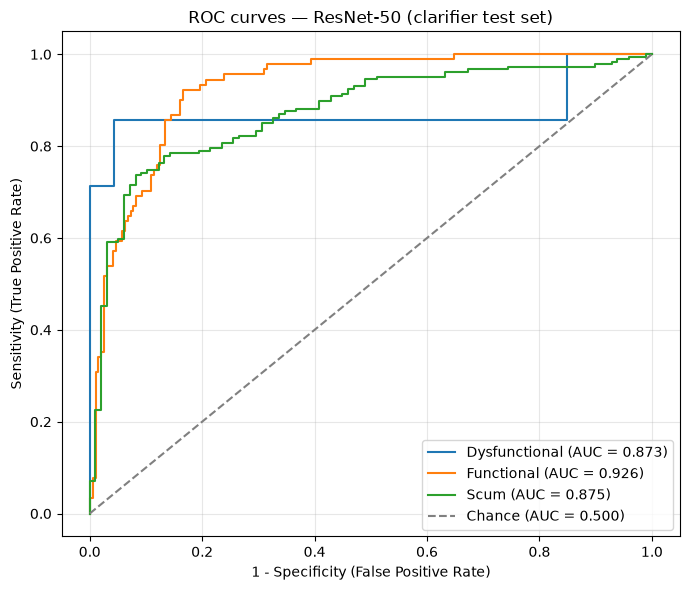

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.873
  Empty          : undefined (0 examples)
  Functional     : 0.926
  Scum           : 0.875

Mean AUC (over 3/4 classes with test examples): 0.891


(np.float64(0.7992957746478874),
 {'Dysfunctional': 0.8726147498710676,
  'Empty': nan,
  'Functional': 0.9264931959232477,
  'Scum': 0.8746434057493965})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/results_clarifier_resnet50_Waterval.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
